# Customer Churn Prediction

## 1. Introduction

This project aims to build a machine learning model that predicts whether a telecom customer is likely to churn based on their demographic information, service usage, contract details, and billing information.
The project covers data exploration, data cleaning, exploratory data analysis, feature preparation, model training, and model evaluation.

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [82]:
import joblib

## 3. Load Dataset

In [5]:
df=pd.read_csv(r"D:\Downloads\archive\WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 4. Initial Data Exploration

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## 5. Data Quality Check

Before training the machine learning model, we need to check the dataset for missing values, duplicate records, incorrect data types, and inconsistent values.

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [16]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [17]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(11)

In [18]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## 6. Data Cleaning

The `TotalCharges` column was initially stored as an object because it contained blank values. These values were converted to `NaN` using numeric conversion with `errors="coerce"`.

Since the affected customers had a tenure of zero months, the missing `TotalCharges` values were replaced with 0. The column was then verified to have a numeric data type and no remaining missing values.

In [19]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [20]:
df["TotalCharges"].dtype

dtype('float64')

In [21]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [22]:
df["TotalCharges"]=df["TotalCharges"].fillna(0)

In [23]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 7. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand customer characteristics and identify patterns associated with customer churn.

In [26]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

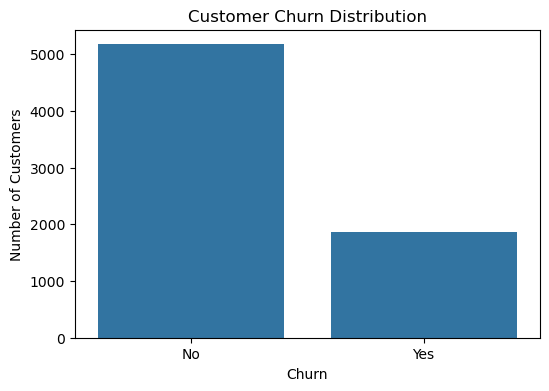

In [27]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


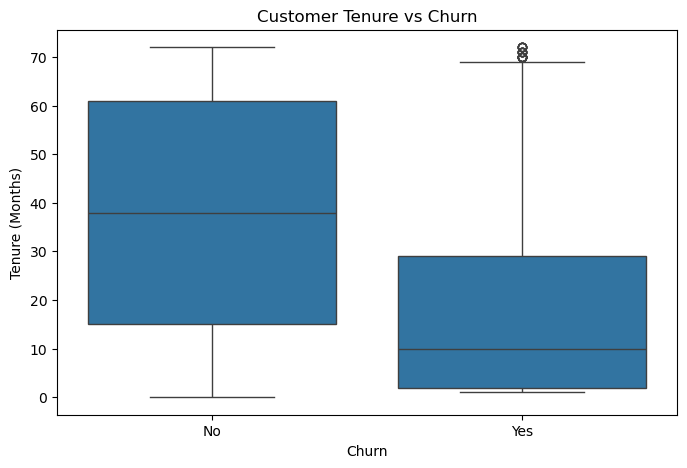

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Tenure vs Churn

The analysis shows that customers with shorter tenure tend to have a higher likelihood of churn. Long-term customers generally show lower churn compared with newer customers.

This suggests that customer retention efforts may be particularly important during the early stages of the customer relationship.

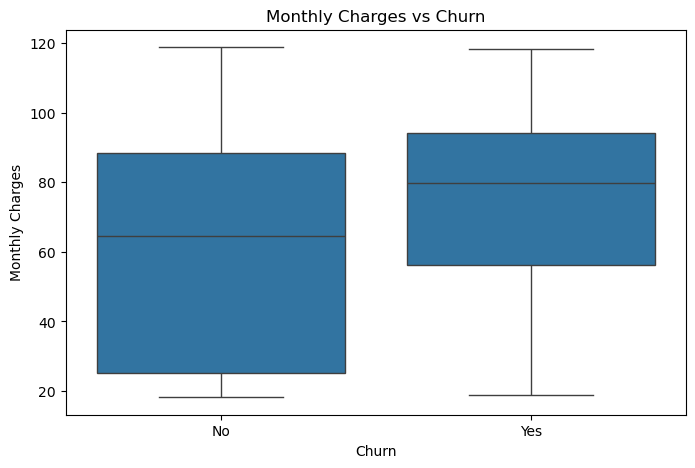

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Monthly Charges vs Churn

The analysis indicates that customers with higher monthly charges tend to have a higher likelihood of churn compared with customers paying lower monthly charges.

This may indicate that pricing or perceived value could be an important factor influencing customer retention.

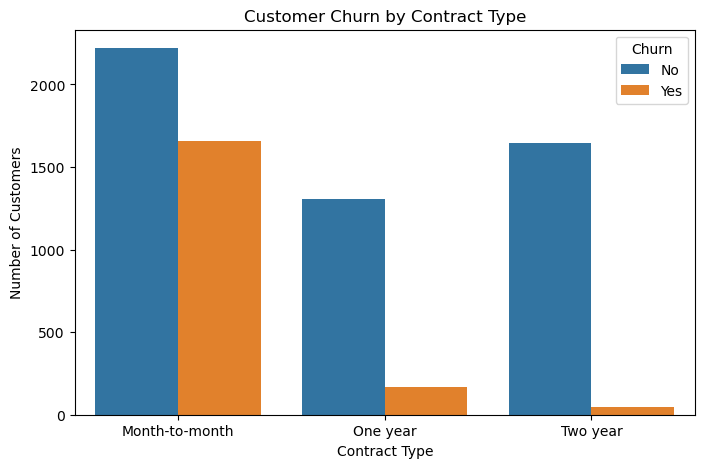

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Contract Type vs Churn

The analysis shows a significant difference in churn across contract types. Month-to-month customers have substantially higher churn compared with customers on one-year or two-year contracts.

This suggests that customers with longer-term contracts are generally more likely to remain with the company.

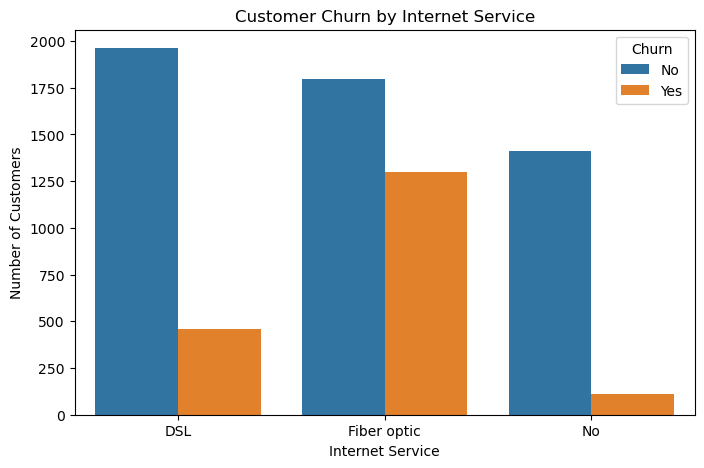

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Internet Service vs Churn

The analysis compares customer churn across different internet service types. The churn rate varies between internet service categories, indicating that the type of internet service may be associated with customer churn.

This feature will be considered during the machine learning stage to determine whether internet service type contributes to accurate churn prediction.

In [33]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [34]:
correlation_matrix = df[numerical_cols].corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


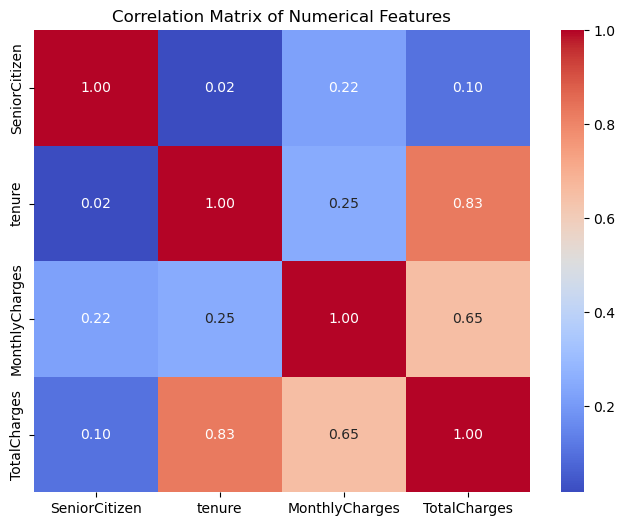

In [35]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [36]:
df = df.drop("customerID", axis=1)

In [37]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [38]:
y = df["Churn"]

In [39]:
X = df.drop("Churn", axis=1)

In [40]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [41]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(include=np.number).columns

In [42]:
print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [43]:

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [46]:
print("Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

Testing set:
Churn
No     73.456352
Yes    26.543648
Name: proportion, dtype: float64


In [47]:
numerical_transformer = StandardScaler()

In [48]:
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [50]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [51]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
y_pred = logistic_model.predict(X_test)

In [53]:
y_pred[:20]

array(['No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No'],
      dtype=object)

In [54]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,No,No
1,No,Yes
2,No,No
3,No,No
4,No,No
5,No,Yes
6,No,No
7,No,No
8,No,No
9,Yes,No


### Model Evaluation

The Logistic Regression model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

Accuracy measures the overall proportion of correct predictions. Precision measures how many customers predicted as churners actually churned, while recall measures how many of the actual churners were successfully identified by the model.

Recall is particularly important in this business problem because failing to identify a customer who is likely to churn may result in a missed opportunity for customer retention.

The confusion matrix provides a detailed view of correct and incorrect predictions, including false positives and false negatives.

In [55]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8055358410220014


In [56]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

print("Precision:", precision)

Precision: 0.6572327044025157


In [57]:
recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

print("Recall:", recall)

Recall: 0.5588235294117647


In [58]:
f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

print("F1-score:", f1)

F1-score: 0.6040462427745664


In [59]:
print("Model Evaluation")
print("-----------------")
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-score : {f1:.2f}")

Model Evaluation
-----------------
Accuracy : 0.81
Precision: 0.66
Recall   : 0.56
F1-score : 0.60


In [60]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

print(cm)

[[926 109]
 [165 209]]


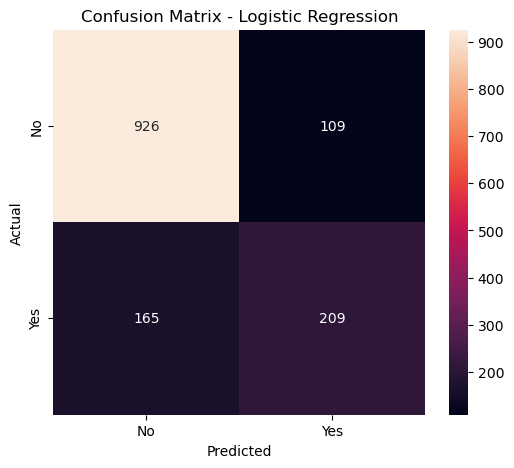

In [61]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [63]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [64]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
rf_pred = random_forest_model.predict(X_test)

In [66]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    pos_label="Yes"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    pos_label="Yes"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    pos_label="Yes"
)

print("Random Forest Evaluation")
print("------------------------")
print(f"Accuracy : {rf_accuracy:.2f}")
print(f"Precision: {rf_precision:.2f}")
print(f"Recall   : {rf_recall:.2f}")
print(f"F1-score : {rf_f1:.2f}")

Random Forest Evaluation
------------------------
Accuracy : 0.78
Precision: 0.62
Recall   : 0.48
F1-score : 0.54


### Model Comparison

Two classification models were evaluated for customer churn prediction: Logistic Regression and Random Forest.

Logistic Regression performed better across all four evaluation metrics. It achieved 81% accuracy, 66% precision, 56% recall, and a 60% F1-score, compared with 78% accuracy, 62% precision, 48% recall, and 54% F1-score for Random Forest.

Since identifying customers who are likely to churn is an important business objective, recall is particularly important. Logistic Regression achieved higher recall and was therefore selected as the better-performing model for this project.

In [67]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1-Score": [f1, rf_f1]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Random Forest,0.783534,0.618557,0.481283,0.541353


### Understanding `class_weight="balanced"`

The dataset is imbalanced, with approximately 73% of customers not churning and 27% churning.

Using `class_weight="balanced"` gives greater importance to the minority class (`Churn = Yes`) during model training. This encourages the model to identify more customers who are likely to churn.

As a result, recall improved from 56% to 78%, meaning the model detected a much larger proportion of actual churners.

However, precision decreased from 66% to 50% because the model also classified more non-churning customers as potential churners.

This demonstrates the trade-off between **recall and precision**. For churn prediction, higher recall can be valuable because missing a customer who is likely to churn may result in a lost retention opportunity.

In [69]:
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

In [70]:
balanced_logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
balanced_pred = balanced_logistic_model.predict(X_test)

In [72]:
balanced_accuracy = accuracy_score(y_test, balanced_pred)

balanced_precision = precision_score(
    y_test,
    balanced_pred,
    pos_label="Yes"
)

balanced_recall = recall_score(
    y_test,
    balanced_pred,
    pos_label="Yes"
)

balanced_f1 = f1_score(
    y_test,
    balanced_pred,
    pos_label="Yes"
)

print("Balanced Logistic Regression")
print("----------------------------")
print(f"Accuracy : {balanced_accuracy:.2f}")
print(f"Precision: {balanced_precision:.2f}")
print(f"Recall   : {balanced_recall:.2f}")
print(f"F1-score : {balanced_f1:.2f}")

Balanced Logistic Regression
----------------------------
Accuracy : 0.74
Precision: 0.50
Recall   : 0.78
F1-score : 0.61


### Final Model Comparison

Three model configurations were evaluated for customer churn prediction: Logistic Regression, Random Forest, and Balanced Logistic Regression.

Logistic Regression provided the highest overall accuracy and precision, while Balanced Logistic Regression achieved the highest recall and F1-score.

Since the primary business objective is to identify customers who are likely to churn, recall is particularly important. The Balanced Logistic Regression model achieved a recall of 78%, compared with 56% for the original Logistic Regression and 48% for Random Forest.

Therefore, Balanced Logistic Regression was selected as the final model for this project. The model prioritizes identifying potential churners, while accepting a lower precision and overall accuracy.

In [73]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        balanced_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        balanced_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        balanced_recall
    ],
    "F1-Score": [
        f1,
        rf_f1,
        balanced_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Random Forest,0.783534,0.618557,0.481283,0.541353
2,Balanced Logistic Regression,0.738112,0.504303,0.783422,0.613613


In [74]:
balanced_cm = confusion_matrix(
    y_test,
    balanced_pred,
    labels=["No", "Yes"]
)

print(balanced_cm)

[[747 288]
 [ 81 293]]


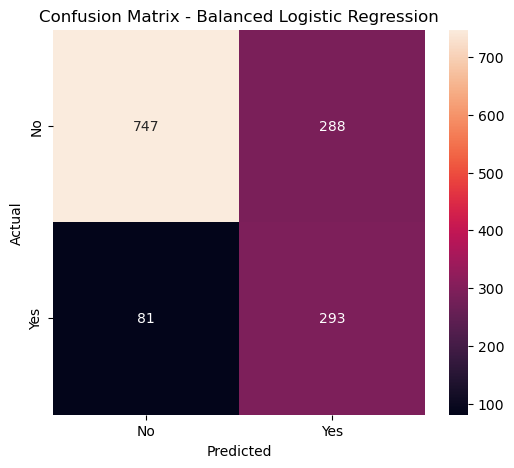

In [75]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    balanced_cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [76]:
feature_names = balanced_logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [77]:
len(feature_names)

45

In [78]:
coefficients = balanced_logistic_model.named_steps[
    "classifier"
].coef_[0]

In [79]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [80]:
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.154434,1.154434
38,cat__Contract_Two year,-0.775518,0.775518
16,cat__InternetService_Fiber optic,0.707981,0.707981
2,num__MonthlyCharges,-0.676114,0.676114
36,cat__Contract_Month-to-month,0.657713,0.657713
15,cat__InternetService_DSL,-0.622465,0.622465
3,num__TotalCharges,0.489698,0.489698
22,cat__OnlineBackup_No internet service,-0.275403,0.275403
31,cat__StreamingTV_No internet service,-0.275403,0.275403
25,cat__DeviceProtection_No internet service,-0.275403,0.275403


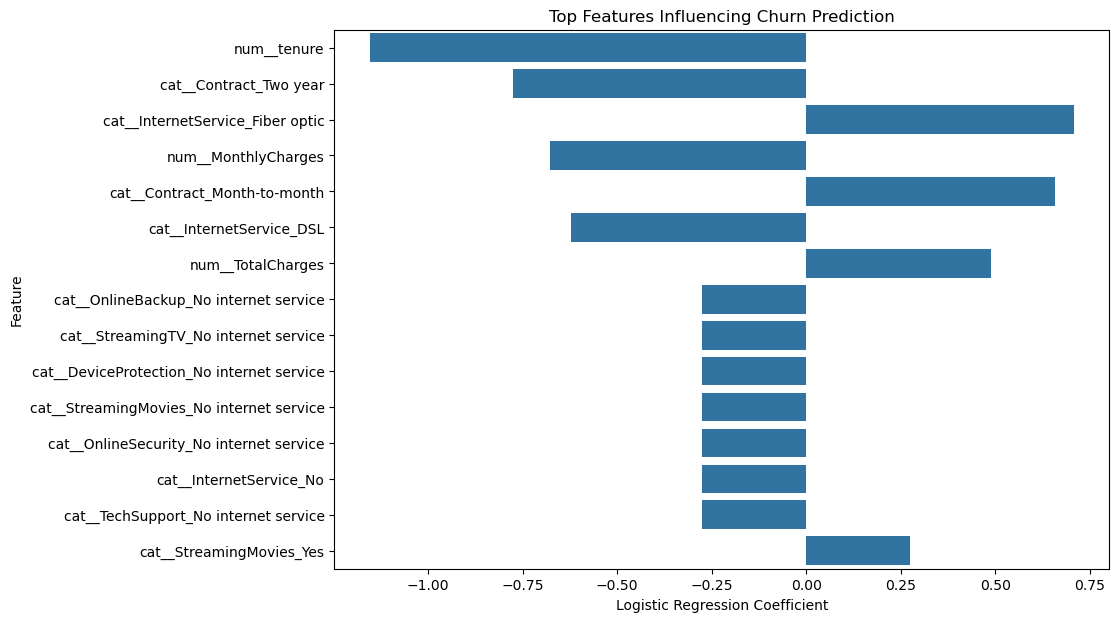

In [81]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Influencing Churn Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

### Saving the Final Model

The final Balanced Logistic Regression pipeline was saved using Joblib.

The complete pipeline includes the preprocessing steps and trained classification model. Saving the pipeline allows the model to be loaded later and used to make predictions on new customer data without repeating the training process.

In [88]:
joblib.dump(
    balanced_logistic_model,
    "telco_churn_model.pkl"
)

['telco_churn_model.pkl']

In [89]:
loaded_model = joblib.load("telco_churn_model.pkl")

In [90]:
test_predictions = loaded_model.predict(X_test.head(5))

test_predictions

array(['No', 'Yes', 'No', 'Yes', 'No'], dtype=object)